# Phase 2 — Teaching the Computer to "Fingerprint" Each Stock

**What we're doing.** We take each stock's last few months of daily ups-and-downs and boil them down to a short list of 12 numbers — a "fingerprint" of how that stock behaved. Two stocks that behaved alike get similar fingerprints.

**Why this helps pairs trading.** A good pair is two stocks that genuinely move together. Plain correlation only notices when two prices rise and fall on the same days; it misses subtler patterns and is slow to react. This tool reads the *shape* of each stock's recent behaviour and squeezes it into a short fingerprint, so stocks that truly behave alike end up with fingerprints that sit close together. Phase 3 then groups those fingerprints to find candidate pairs.

**Why this kind of model rather than a plain data-shrinker.** A plain shrinker would just compress the data as tightly as possible. This model — a *variational autoencoder*, or VAE — does that too, but it also gently arranges the fingerprints into a tidy space where "close together" really does mean "behaves alike". That tidiness is what makes the grouping in Phase 3 trustworthy.

In [22]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

torch.manual_seed(42)
np.random.seed(42)

CUDA available: True
Device: NVIDIA GeForce RTX 3060 Laptop GPU


## Load the training data — 2015–2017 only

Phase 1 produced a stack of normalised 60-day return windows — one per asset per period. Shape `(462 assets × 47 windows × 60 days)`.

**We train the VAE on the first 12 windows only (2015-01 → Nov-2017), then freeze it for the rest of the project.** Everything from 2018 onward is held back as genuinely unseen data.

**Why train on just the early period and freeze.** The fingerprint-maker has to be a *fixed ruler*. If we let it peek at 2020–2026 returns and then later claim our 2020–2026 backtest is "out-of-sample", an examiner would rightly object — the model already saw those patterns. By training once on 2015–2017 and never touching it again, every fingerprint we produce for later years is made by a ruler that has never seen them. That is what makes the walk-forward backtest in the later phases honest.

**Why this is safe, not lossy.** The VAE only learns the *generic shapes* of return windows (calm drift, sharp sell-off, choppy mean-reversion). Those shapes are not unique to 2015–2017 — they recur in every later period — so a frozen 2015–2017 encoder still produces sensible fingerprints for a 2024 window; it just never got to memorise that window.

For training we take windows 0–11 of every asset and flatten each (asset, window) pair into one independent example.

**Why flatten.** We want the fingerprint to describe *how* an asset behaved in a window, not *which* asset it is. By mixing all asset-windows into one pile, the encoder is forced to learn patterns that transfer across companies — exactly what we need when we later ask *"which two different stocks behaved similarly?"* to build pairs.

In [23]:
X = np.load("data/model_input/tensor_norm.npy")        # (462, 47, 60)
print(f"Full tensor: {X.shape}  (assets x windows x days)")

TRAIN_WINDOWS = 12                                     # windows 0-11 = 2015-01 -> Nov-2017
X = X[:, :TRAIN_WINDOWS, :].reshape(-1, X.shape[-1])
print(f"Training subset (windows 0-{TRAIN_WINDOWS-1}, 2015-2017): {X.shape}  (samples x days)")

Full tensor: (462, 47, 60)  (assets x windows x days)
Training subset (windows 0-11, 2015-2017): (5544, 60)  (samples x days)


## Train / validation split (within the 2015–2017 window)

Random 80/20 split of the 2015–2017 asset-windows, fixed seed. The 20% validation set is used only to decide *when to stop training* (early stopping) and to confirm the VAE generalises to windows it didn't update on — it is **not** the out-of-sample test.

**Why a random split is fine here.** The real out-of-sample test is structural and happens in the later phases: the *frozen* encoder is applied to 2020+ windows it has never seen, and the strategy is backtested there. At this stage we only need to confirm the architecture converges and doesn't overfit, for which a random split inside the training window is the simplest honest check. The time-ordered separation that actually matters (train on 2015–2017, trade on 2020+) is already enforced by the window slice above.

In [24]:
perm = np.random.permutation(len(X))
split = int(0.8 * len(X))
X_train = torch.tensor(X[perm[:split]], dtype=torch.float32)
X_val   = torch.tensor(X[perm[split:]], dtype=torch.float32)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")

Train: torch.Size([4435, 60]) | Val: torch.Size([1109, 60])


## The handful of settings we chose

- **Fingerprint size = 12 numbers.** Enough detail to tell stocks apart, but not so much that every stock looks unique. The middle of the range used in similar studies.
- **Network shape 60 → 128 → 64 → 12.** The data is squeezed down in gentle steps rather than all at once, so little is lost on the way.
- **Learning speed = 0.001.** A standard, steady setting — fast enough to finish in a few minutes, slow enough to settle smoothly.
- **Batch size = 256.** How many examples the model looks at before each small adjustment; this fits comfortably in the laptop's graphics memory.
- **Up to 100 passes, but stop early if it stalls.** We allow up to 100 rounds of learning but stop the moment it stops improving — a clean, non-arbitrary place to halt.
- **Balance dial = 1.0.** How much weight we put on "keep the fingerprints tidy" versus "rebuild the data accurately". The standard, even setting; other settings are left for future work.

In [25]:
LATENT_DIM = 12
HIDDEN     = [128, 64]
LR         = 1e-3
BATCH      = 256
EPOCHS     = 100
PATIENCE   = 10
BETA       = 1.0

## The model's two halves

It has two mirror-image halves:
- **The encoder** takes a stock's 60-day pattern and boils it down to the 12-number fingerprint.
- **The decoder** takes that fingerprint and tries to rebuild the original 60-day pattern.

If the decoder can rebuild the pattern well, the fingerprint must have captured what matters. The decoder is only a training aid — once training is done we keep the encoder and throw the decoder away.

**One twist that makes the space tidy.** Instead of pinning each stock to a single exact point, the encoder places it as a small *fuzzy blob* of nearby possibilities. Training with fuzzy blobs forces look-alike stocks together and pushes different ones apart: if two very different stocks were parked next to each other, their blobs would overlap, the decoder would get confused, and the model would be penalised. That gentle pressure is exactly the "close = alike" property pairs trading needs.

*(Technical aside, safe to skip: picking a random point from each blob in a way that still lets the model learn is done with the standard "reparameterisation" trick.)*

In [26]:
class VAE(nn.Module):
    def __init__(self, input_dim=60, hidden=(128, 64), latent_dim=12):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, hidden[0]), nn.ReLU(),
            nn.Linear(hidden[0], hidden[1]), nn.ReLU(),
        )
        self.mu     = nn.Linear(hidden[1], latent_dim)
        self.logvar = nn.Linear(hidden[1], latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden[1]), nn.ReLU(),
            nn.Linear(hidden[1], hidden[0]), nn.ReLU(),
            nn.Linear(hidden[0], input_dim),
        )

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        h = self.enc(x)
        mu, logvar = self.mu(h), self.logvar(h)
        z = self.reparameterise(mu, logvar)
        return self.dec(z), mu, logvar

model = VAE(60, HIDDEN, LATENT_DIM).to(device)
print(model)

VAE(
  (enc): Sequential(
    (0): Linear(in_features=60, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=64, out_features=12, bias=True)
  (logvar): Linear(in_features=64, out_features=12, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=60, bias=True)
  )
)


## How we score the model while it learns

The score has two parts added together:
1. **Rebuild error** — how far the decoder's rebuilt pattern is from the original. If this stays high, the fingerprint isn't capturing enough, and any pairs built on it would be unreliable.
2. **Tidiness** — a gentle nudge that keeps all the fingerprints gathered in one neat region instead of scattered everywhere. Without it, the model could fling look-alikes far apart and still rebuild them — useless for the grouping step, which relies on "close = alike".

We track the two parts separately because they flag different problems:
- **Tidiness near zero** → the model is ignoring the fingerprints (no information is being stored).
- **Rebuild error stuck high** → the fingerprints are too cramped to capture real behaviour.

In [27]:
def elbo_loss(x, x_hat, mu, logvar, beta=1.0):
    recon = ((x - x_hat) ** 2).sum(dim=1).mean()
    kl    = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()
    return recon + beta * kl, recon, kl

## Training

A standard learning loop: show the model batches of examples, score it, nudge it to do a little better, and repeat. After each full pass over the data we check the score on the held-aside set and keep the best version so far. Training stops automatically once that score hasn't improved for 10 passes in a row. Each pass prints both score parts so we can watch for the two problems described above.

In [28]:
Path("models/vae").mkdir(parents=True, exist_ok=True)

train_loader = DataLoader(TensorDataset(X_train), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=BATCH)

opt = torch.optim.Adam(model.parameters(), lr=LR)

history = []
best_val = float("inf")
patience = 0

for epoch in range(EPOCHS):
    model.train()
    tr_tot = tr_rec = tr_kl = n_tr = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        x_hat, mu, logvar = model(xb)
        loss, recon, kl = elbo_loss(xb, x_hat, mu, logvar, BETA)
        opt.zero_grad(); loss.backward(); opt.step()
        b = len(xb)
        tr_tot += loss.item() * b; tr_rec += recon.item() * b; tr_kl += kl.item() * b; n_tr += b

    model.eval()
    va_tot = va_rec = va_kl = n_va = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            xb = xb.to(device)
            x_hat, mu, logvar = model(xb)
            loss, recon, kl = elbo_loss(xb, x_hat, mu, logvar, BETA)
            b = len(xb)
            va_tot += loss.item() * b; va_rec += recon.item() * b; va_kl += kl.item() * b; n_va += b

    row = {"epoch": epoch,
           "train_loss": tr_tot/n_tr, "train_recon": tr_rec/n_tr, "train_kl": tr_kl/n_tr,
           "val_loss":   va_tot/n_va, "val_recon":   va_rec/n_va, "val_kl":   va_kl/n_va}
    history.append(row)
    print(f"Ep {epoch:3d} | train {row['train_loss']:.3f} (r {row['train_recon']:.3f}, kl {row['train_kl']:.3f}) "
          f"| val {row['val_loss']:.3f} (r {row['val_recon']:.3f}, kl {row['val_kl']:.3f})")

    if row["val_loss"] < best_val:
        best_val = row["val_loss"]
        patience = 0
        torch.save(model.state_dict(), "models/vae/vae_best.pt")
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f"Early stopped at epoch {epoch} (best val {best_val:.4f})")
            break

pd.DataFrame(history).to_csv("models/vae/training_log.csv", index=False)
with open("models/vae/hparams.json", "w") as f:
    json.dump({"latent_dim": LATENT_DIM, "hidden": HIDDEN, "lr": LR, "batch": BATCH,
               "epochs_max": EPOCHS, "patience": PATIENCE, "beta": BETA, "seed": 42,
               "best_val_loss": best_val}, f, indent=2)
print(f"\nBest val loss: {best_val:.4f}")

Ep   0 | train 59.447 (r 59.385, kl 0.062) | val 58.946 (r 58.895, kl 0.050)
Ep   1 | train 58.867 (r 58.789, kl 0.078) | val 58.756 (r 58.638, kl 0.118)
Ep   2 | train 58.668 (r 58.472, kl 0.196) | val 58.479 (r 58.148, kl 0.331)
Ep   3 | train 58.047 (r 57.288, kl 0.758) | val 57.248 (r 55.888, kl 1.359)
Ep   4 | train 56.493 (r 54.941, kl 1.552) | val 55.854 (r 54.042, kl 1.812)
Ep   5 | train 54.817 (r 52.403, kl 2.413) | val 54.034 (r 51.347, kl 2.686)
Ep   6 | train 53.394 (r 50.495, kl 2.899) | val 52.596 (r 49.342, kl 3.254)
Ep   7 | train 52.139 (r 48.548, kl 3.591) | val 51.462 (r 47.491, kl 3.971)
Ep   8 | train 50.943 (r 46.779, kl 4.163) | val 50.387 (r 46.106, kl 4.281)
Ep   9 | train 49.953 (r 45.441, kl 4.512) | val 49.630 (r 45.032, kl 4.598)
Ep  10 | train 49.128 (r 44.341, kl 4.787) | val 48.768 (r 43.842, kl 4.925)
Ep  11 | train 48.606 (r 43.546, kl 5.059) | val 48.515 (r 43.348, kl 5.167)
Ep  12 | train 48.198 (r 43.063, kl 5.135) | val 48.129 (r 42.819, kl 5.310)

## The learning curves

Three small charts — the total score, the rebuild-error part, and the tidiness part — each plotted over the training passes.

**How to read them (what healthy looks like):**
- **Total score** should fall and then flatten out.
- **Rebuild error** should fall clearly — the model is learning the shape of the patterns.
- **Tidiness** usually rises early (the fingerprints start carrying real information) and then settles. If it stayed flat at zero, that would be the warning sign that the model is ignoring the fingerprints.

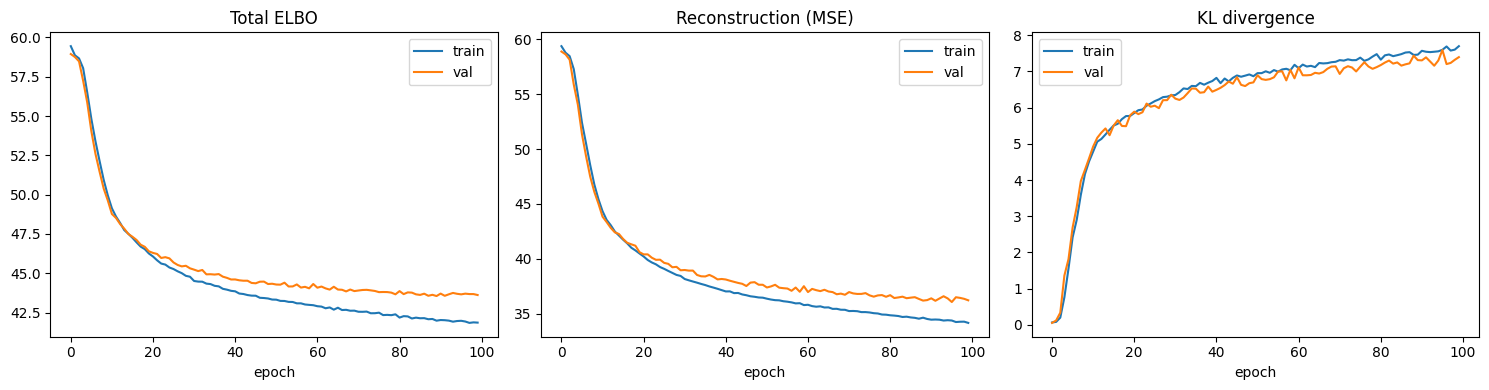

In [29]:
h = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col_tr, col_va, title) in zip(axes, [
    ("train_loss",  "val_loss",  "Total ELBO"),
    ("train_recon", "val_recon", "Reconstruction (MSE)"),
    ("train_kl",    "val_kl",    "KL divergence"),
]):
    ax.plot(h.epoch, h[col_tr], label="train")
    ax.plot(h.epoch, h[col_va], label="val")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout(); plt.show()

## Does it rebuild patterns it has never seen?

A quick eyeball test: for a few held-aside examples the model never trained on, we overlay the original 60-day pattern and the model's rebuilt version.

**How to read it:** we want the rebuilt line to follow the *overall shape* of the original — not trace it exactly (that would just be copying noise), but capture the main ups and downs. Flat rebuilds, or ones that follow nothing, would mean the fingerprints aren't carrying useful information.

C:\Users\lalit\AppData\Local\Temp\ipykernel_11228\1104762395.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/vae/vae_best.pt"))


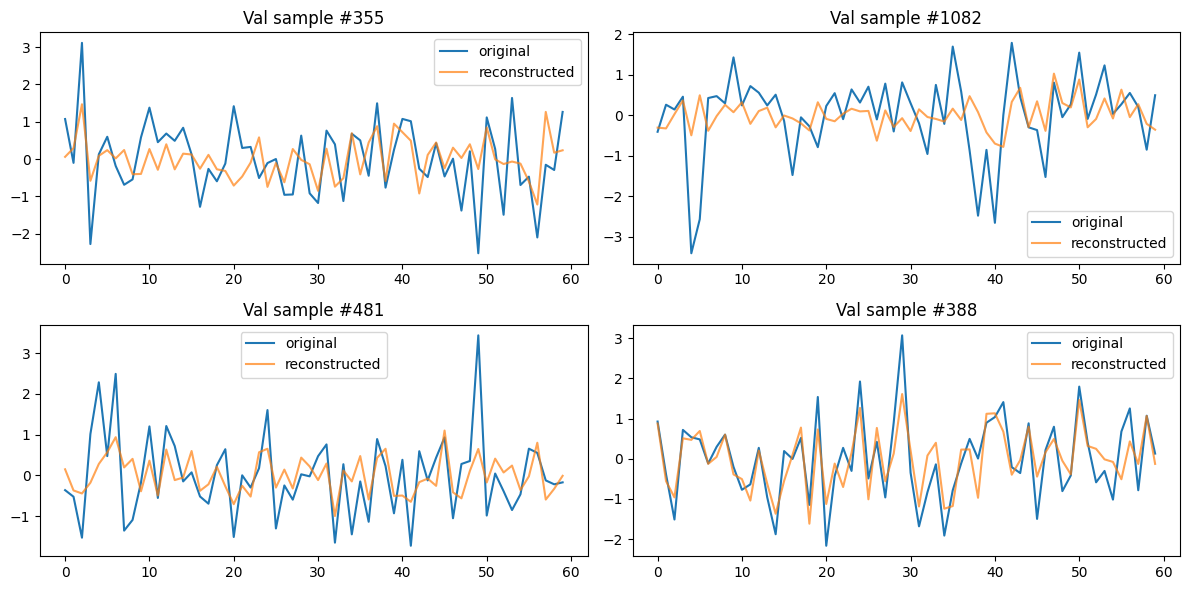

Mean per-element val MSE: 0.6039


In [30]:
model.load_state_dict(torch.load("models/vae/vae_best.pt"))
model.eval()

idx = np.random.choice(len(X_val), 4, replace=False)
with torch.no_grad():
    xb = X_val[idx].to(device)
    x_hat, _, _ = model(xb)
xb, x_hat = xb.cpu().numpy(), x_hat.cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.plot(xb[i],    label="original")
    ax.plot(x_hat[i], label="reconstructed", alpha=0.7)
    ax.set_title(f"Val sample #{idx[i]}"); ax.legend()
plt.tight_layout(); plt.show()

with torch.no_grad():
    all_hat, _, _ = model(X_val.to(device))
val_mse = ((X_val.numpy() - all_hat.cpu().numpy()) ** 2).mean()
print(f"Mean per-element val MSE: {val_mse:.4f}")

## Encode every window with the frozen VAE

Now the key step. We push **all 47 windows** of every asset — including the 2018–2026 windows the VAE never trained on — through the frozen encoder and keep only the **centre** (`mu`) of each window's fuzzy cloud. Using the centre (not a random draw) makes the output deterministic and reproducible, which the latent-inspection and clustering steps need.

This is the frozen-ruler idea in action: a 2015–2017 encoder measuring later years it has never seen. Output shape `(462 assets × 47 windows × 12)`, saved to `data/model_input/latent_vectors.npy` — the handoff to Phase 2's latent inspection and Phase 3's clustering.

In [31]:
X_all = torch.tensor(np.load("data/model_input/tensor_norm.npy").reshape(-1, 60), dtype=torch.float32)

latents = []
model.eval()
with torch.no_grad():
    for i in range(0, len(X_all), BATCH):
        h = model.enc(X_all[i:i+BATCH].to(device))
        latents.append(model.mu(h).cpu().numpy())

Z = np.concatenate(latents).reshape(462, 47, LATENT_DIM)
np.save("data/model_input/latent_vectors.npy", Z)

print(f"Saved latent_vectors.npy: {Z.shape}")
print(f"Any NaN: {np.isnan(Z).any()} | Any Inf: {np.isinf(Z).any()}")
print(f"Per-dim mean: {Z.reshape(-1, LATENT_DIM).mean(0).round(3)}")
print(f"Per-dim std:  {Z.reshape(-1, LATENT_DIM).std(0).round(3)}")

Saved latent_vectors.npy: (462, 47, 12)
Any NaN: False | Any Inf: False
Per-dim mean: [ 0.053 -0.114  0.003 -0.169 -0.034  0.023 -0.011 -0.039  0.002  0.095
  0.088  0.05 ]
Per-dim std:  [0.681 0.676 0.669 0.703 0.704 0.674 0.048 0.478 0.065 0.682 0.688 0.297]
